# 1. IMPORTS AND SETUP

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Configure visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. DATA LOADING AND INITIAL INSPECTION

In [2]:

print("Loading dataset...")
df = pd.read_csv("student_mental_health_burnout.csv")

# Display basic dataset information
print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Only show columns with missing values

print("\n--- First 5 Rows ---")
display(df.head())

Loading dataset...

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     1500

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


# 3. EXPLORATORY DATA ANALYSIS (EDA): TARGET DISTRIBUTION

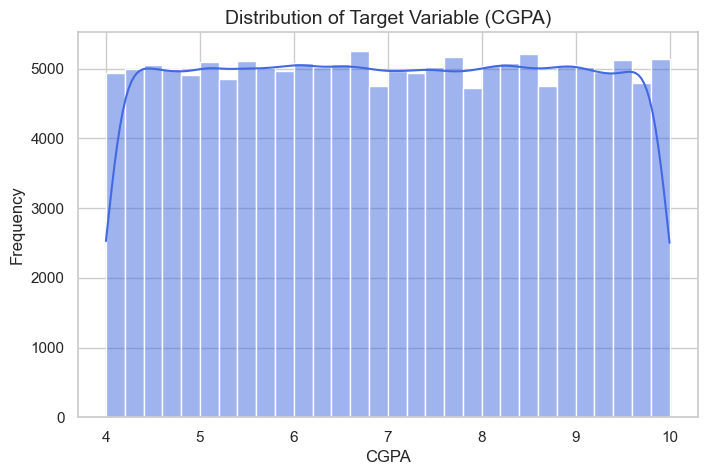

Target Variable (CGPA) Summary Statistics:
count    150000.000000
mean          6.997389
std           1.732180
min           4.000000
25%           5.500000
50%           6.990000
75%           8.500000
max          10.000000
Name: cgpa, dtype: float64


In [3]:

# Analyze the distribution of the target variable (CGPA)

plt.figure(figsize=(8, 5))
sns.histplot(df['cgpa'], bins=30, kde=True, color='royalblue')
plt.title("Distribution of Target Variable (CGPA)", fontsize=14)
plt.xlabel("CGPA")
plt.ylabel("Frequency")
plt.show()

# Display summary statistics for the target
print("Target Variable (CGPA) Summary Statistics:")
print(df['cgpa'].describe())

# 4. EXPLORATORY DATA ANALYSIS (EDA): CORRELATION ANALYSIS

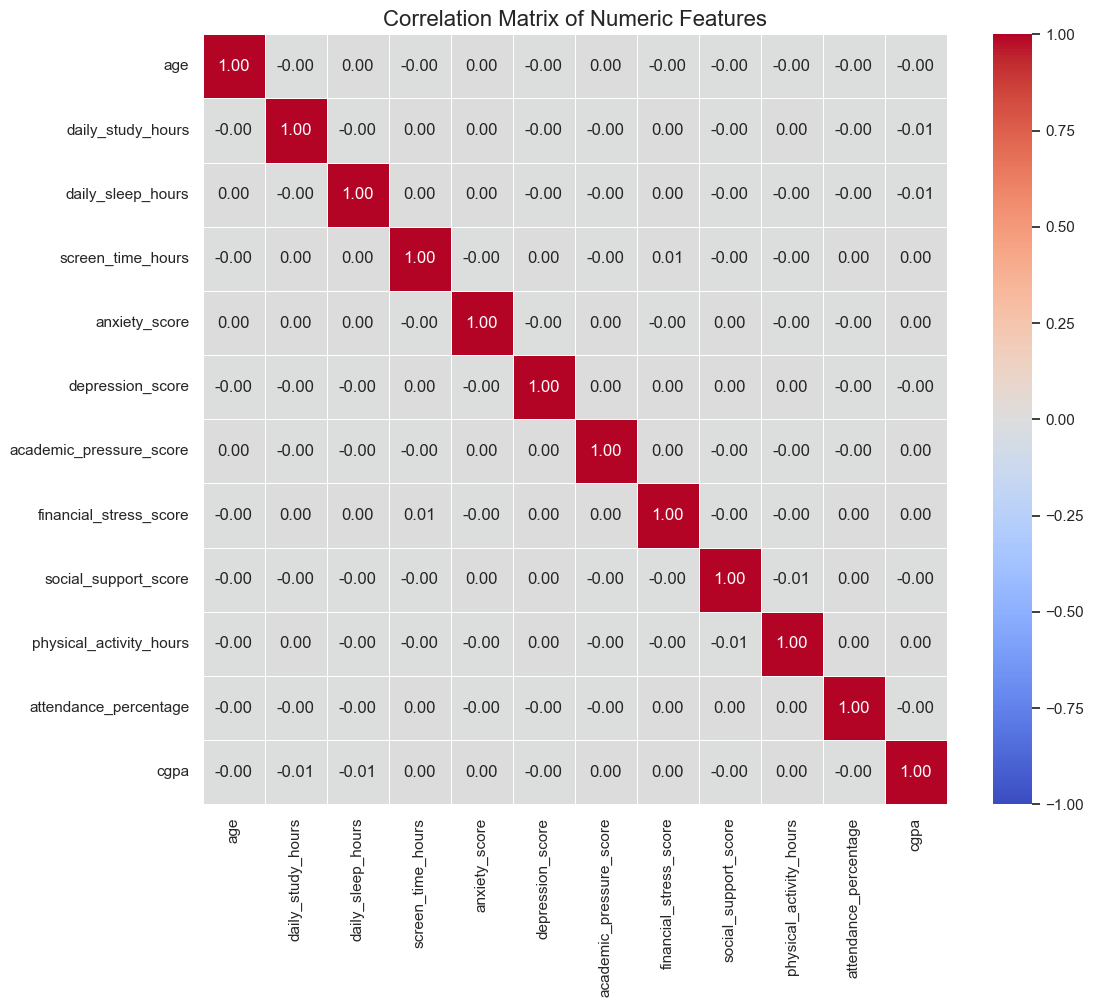

In [4]:

# Visualize linear correlations between numeric features

# Isolate numeric columns for the correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].drop(columns=['student_id'], errors='ignore').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

# 5. DATA PREPROCESSING

In [5]:

print("Preprocessing data for feature selection...")

# Drop identifier columns not useful for prediction
df_processed = df.drop(columns=['student_id'], errors='ignore')

# Separate features (X) and target (y)
X_raw = df_processed.drop(columns=['cgpa'])
y = df_processed['cgpa']

# Encode categorical variables using One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True)

# Perform Train-Test Split (80/20) to prevent data leakage during feature selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape: {X_test.shape}")

Preprocessing data for feature selection...
Training feature set shape: (120000, 29)
Testing feature set shape: (30000, 29)


# 6. FILTER METHOD: MUTUAL INFORMATION

Executing Filter Method: Mutual Information Regression...


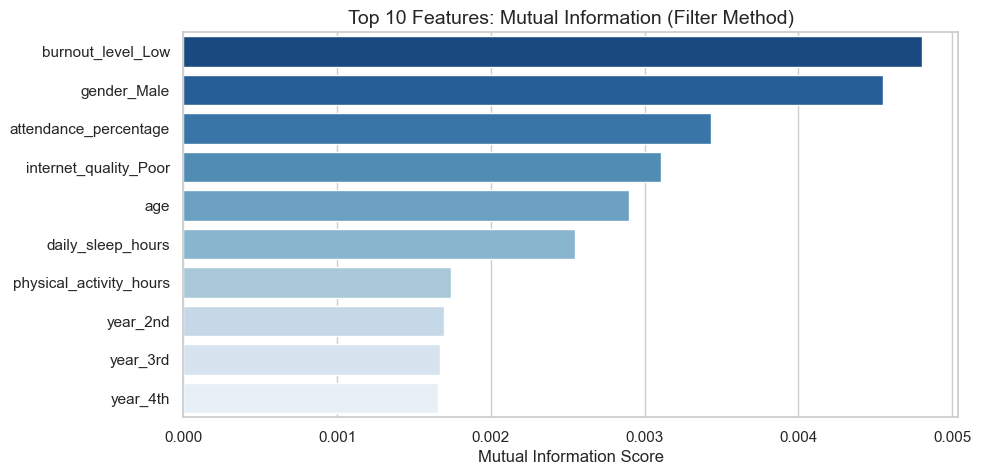

Top 5 Filter Features: ['burnout_level_Low', 'gender_Male', 'attendance_percentage', 'internet_quality_Poor', 'age']


In [11]:

print("Executing Filter Method: Mutual Information Regression...")

# Calculate Mutual Information scores
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

# Structure results into a DataFrame
df_mi = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
df_mi = df_mi.sort_values(by='MI_Score', ascending=False)

# Extract top 5 features
top_5_filter = df_mi['Feature'].head(5).tolist()

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='MI_Score', y='Feature', hue='Feature', data=df_mi.head(10), palette='Blues_r', legend=False)
plt.title("Top 10 Features: Mutual Information (Filter Method)", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("")
plt.show()

print(f"Top 5 Filter Features: {top_5_filter}")

# 7. WRAPPER METHOD: RECURSIVE FEATURE ELIMINATION (RFE)

Executing Wrapper Method: Recursive Feature Elimination...


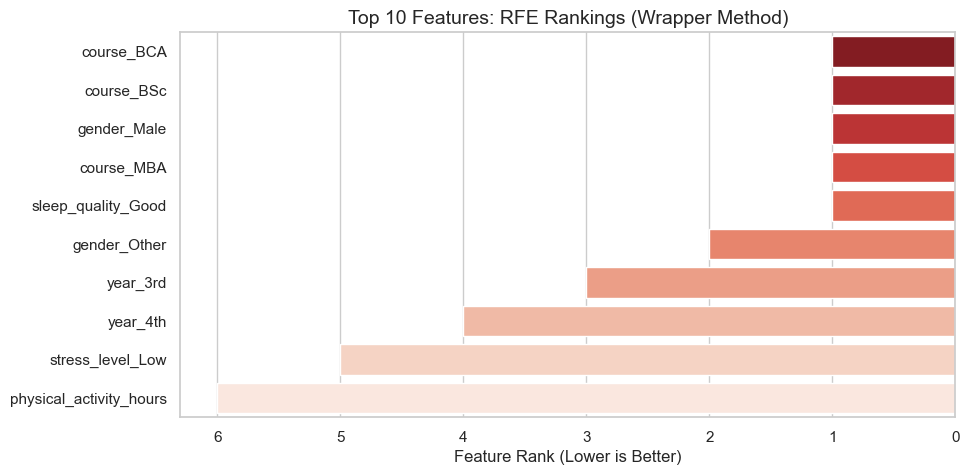

Top 5 Wrapper Features: ['course_BCA', 'course_BSc', 'gender_Male', 'course_MBA', 'sleep_quality_Good']


In [12]:

print("Executing Wrapper Method: Recursive Feature Elimination...")

# Initialize base estimator
estimator = LinearRegression()

# Configure RFE to select top 5 features
rfe = RFE(estimator=estimator, n_features_to_select=5, step=1)
rfe.fit(X_train, y_train)

# Structure results into a DataFrame
df_rfe = pd.DataFrame({'Feature': X_train.columns, 'Rank': rfe.ranking_})
df_rfe = df_rfe.sort_values(by='Rank')

# Extract top 5 features (Rank == 1)
top_5_wrapper = df_rfe[df_rfe['Rank'] == 1]['Feature'].tolist()

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='Rank', y='Feature', hue='Feature', data=df_rfe.head(10), palette='Reds_r', legend=False)
plt.title("Top 10 Features: RFE Rankings (Wrapper Method)", fontsize=14)
plt.xlabel("Feature Rank (Lower is Better)")
plt.ylabel("")
plt.gca().invert_xaxis() # Lower rank (better) on the right
plt.show()

print(f"Top 5 Wrapper Features: {top_5_wrapper}")

# 8. EMBEDDED METHOD: RANDOM FOREST FEATURE IMPORTANCE

Executing Embedded Method: Random Forest...


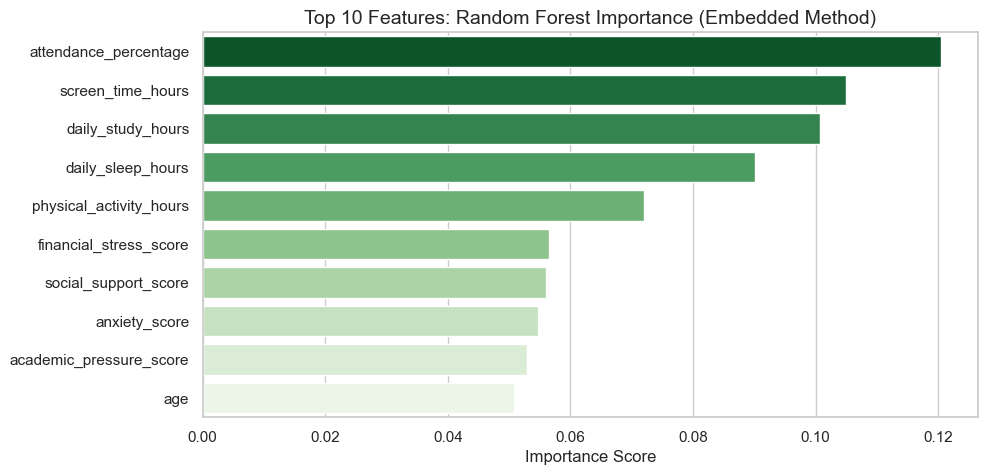

Top 5 Embedded Features: ['attendance_percentage', 'screen_time_hours', 'daily_study_hours', 'daily_sleep_hours', 'physical_activity_hours']


In [13]:

print("Executing Embedded Method: Random Forest...")

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extract feature importances
df_rf = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': rf_model.feature_importances_
})
df_rf = df_rf.sort_values(by='Importance', ascending=False)

# Extract top 5 features
top_5_embedded = df_rf['Feature'].head(5).tolist()

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_rf.head(10), palette='Greens_r', legend=False)
plt.title("Top 10 Features: Random Forest Importance (Embedded Method)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("")
plt.show()

print(f"Top 5 Embedded Features: {top_5_embedded}")

# 9. FINAL EVALUATION AND COMPARISON

Evaluating Feature Selection Methods on Test Set...



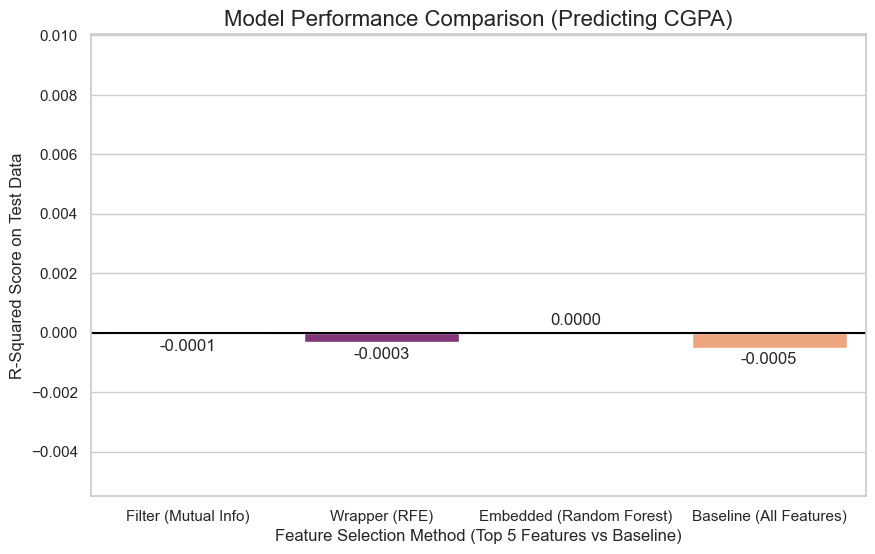

In [14]:
print("Evaluating Feature Selection Methods on Test Set...\n")

def evaluate_feature_subset(feature_list, method_name):
    """Trains a Linear Regression model on a subset of features and returns the R2 score."""
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    model = LinearRegression()
    model.fit(X_train_sub, y_train)
    
    y_pred = model.predict(X_test_sub)
    score = r2_score(y_test, y_pred)
    return score

# Dictionary to hold the final R2 scores
evaluation_results = {
    'Filter (Mutual Info)': evaluate_feature_subset(top_5_filter, "Filter"),
    'Wrapper (RFE)': evaluate_feature_subset(top_5_wrapper, "Wrapper"),
    'Embedded (Random Forest)': evaluate_feature_subset(top_5_embedded, "Embedded"),
    'Baseline (All Features)': evaluate_feature_subset(X_train.columns.tolist(), "Baseline")
}

# Convert to DataFrame for visualization
df_eval = pd.DataFrame(list(evaluation_results.items()), columns=['Method', 'R2_Score'])

# Visualization
plt.figure(figsize=(10, 6))
# Using hue and legend=False to prevent FutureWarnings
ax = sns.barplot(x='Method', y='R2_Score', hue='Method', data=df_eval, palette='magma', legend=False)
plt.title("Model Performance Comparison (Predicting CGPA)", fontsize=16)
plt.xlabel("Feature Selection Method (Top 5 Features vs Baseline)")
plt.ylabel("R-Squared Score on Test Data")

# FIX: Dynamically scale the y-axis to allow negative bars to be visible
min_score = df_eval['R2_Score'].min()
max_score = df_eval['R2_Score'].max()
plt.ylim(min_score - 0.005, max(max_score + 0.01, 0.01)) 

# Draw a solid black line exactly at 0 for visual reference
plt.axhline(0, color='black', linewidth=1.5)

# Annotate bars with exact values
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=3)

plt.show()